# SED Reconstruction with Ensemble Method

This notebook demonstrates the ensemble reconstruction strategy for robust SED estimation from SPHEREx photometry. The ensemble method runs multiple independent reconstructions with different random seeds to provide uncertainty quantification and improve robustness.

## Key Features of Ensemble Method

- **Multiple Independent Runs**: Configurable number of ensemble members with different random seeds
- **Uncertainty Quantification**: Standard deviation across ensemble members provides uncertainty estimates
- **Robust Aggregation**: Both mean and median spectra provided for robustness
- **Quality Assessment**: Automatic quality metrics for each ensemble member
- **Reproducible Results**: Base random seed ensures reproducible ensemble generation

In [1]:
# Import essential libraries
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.interpolate import interp1d
import warnings
from pathlib import Path
import json
import pandas as pd

# Import SPXQuery SED reconstruction modules
from spxquery.sed import SEDConfig
from spxquery.sed.data_loader import BandData
from spxquery.sed.reconstruction import SEDReconstructor

np.random.seed(42)

# Set up matplotlib for better plots
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Check computational device
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using computational device: {device}")

Using computational device: mps


## 1. Target Spectrum Generation

Create a synthetic spectrum with configurable components for testing reconstruction capabilities. This is the same data generation approach used in the main demo notebook.

In [2]:
# === Spectrum Definition Parameters ===
# In convenience, we use a standard sigma value as unit of many of following definitions
sigma = 0.02  # Standard width unit (microns)

# Wavelength range (microns) - SPHEREX coverage
wavelength_center = 2.0  # Central wavelength (microns)
window_width = 60  # Range in units of sigma
n_pixels = 10000  # Should be a relatively large number but does not affect the test at all

wavelength_min = wavelength_center - window_width / 2 * sigma  # Lower bound in microns
wavelength_max = wavelength_center + window_width / 2 * sigma  # Upper bound in microns

# First Gaussian Emission Line
line1_center = wavelength_center - 2 * sigma  # Central wavelength (microns)
line1_amplitude = 150.0  # Peak flux (arbitrary units)
line1_width = sigma  # Width parameter (microns, FWHM ≈ 2.355 * width)

# Second Gaussian Emission Line
line2_center = wavelength_center + 2.5 * sigma  # Central wavelength (microns)
line2_amplitude = 75.0  # Peak flux (arbitrary units)
line2_width = 2 * sigma  # Width parameter (microns)

# Linear Continuum Parameters
continuum_amplitude = 20.0  # Continuum flux at reference wavelength
continuum_slope = 10.0  # Slope (flux per micron)
continuum_reference = 2.0  # Reference wavelength (microns)

print("=== Target Spectrum Parameters ===")
print(f"Line 1: Center = {line1_center:.3f} μm, Amplitude = {line1_amplitude:.1f}, Width = {line1_width:.4f} μm")
print(f"Line 2: Center = {line2_center:.3f} μm, Amplitude = {line2_amplitude:.1f}, Width = {line2_width:.4f} μm")
print(f"Line separation: {abs(line2_center - line1_center):.3f} μm")
print(f"Continuum: {continuum_amplitude:.1f} at {continuum_reference:.1f} μm, slope = {continuum_slope:.1f} μm^-1")
print(f"Spectral resolution: {n_pixels} pixels from {wavelength_min:.1f}-{wavelength_max:.1f} μm")

=== Target Spectrum Parameters ===
Line 1: Center = 1.960 μm, Amplitude = 150.0, Width = 0.0200 μm
Line 2: Center = 2.050 μm, Amplitude = 75.0, Width = 0.0400 μm
Line separation: 0.090 μm
Continuum: 20.0 at 2.0 μm, slope = 10.0 μm^-1
Spectral resolution: 10000 pixels from 1.4-2.6 μm


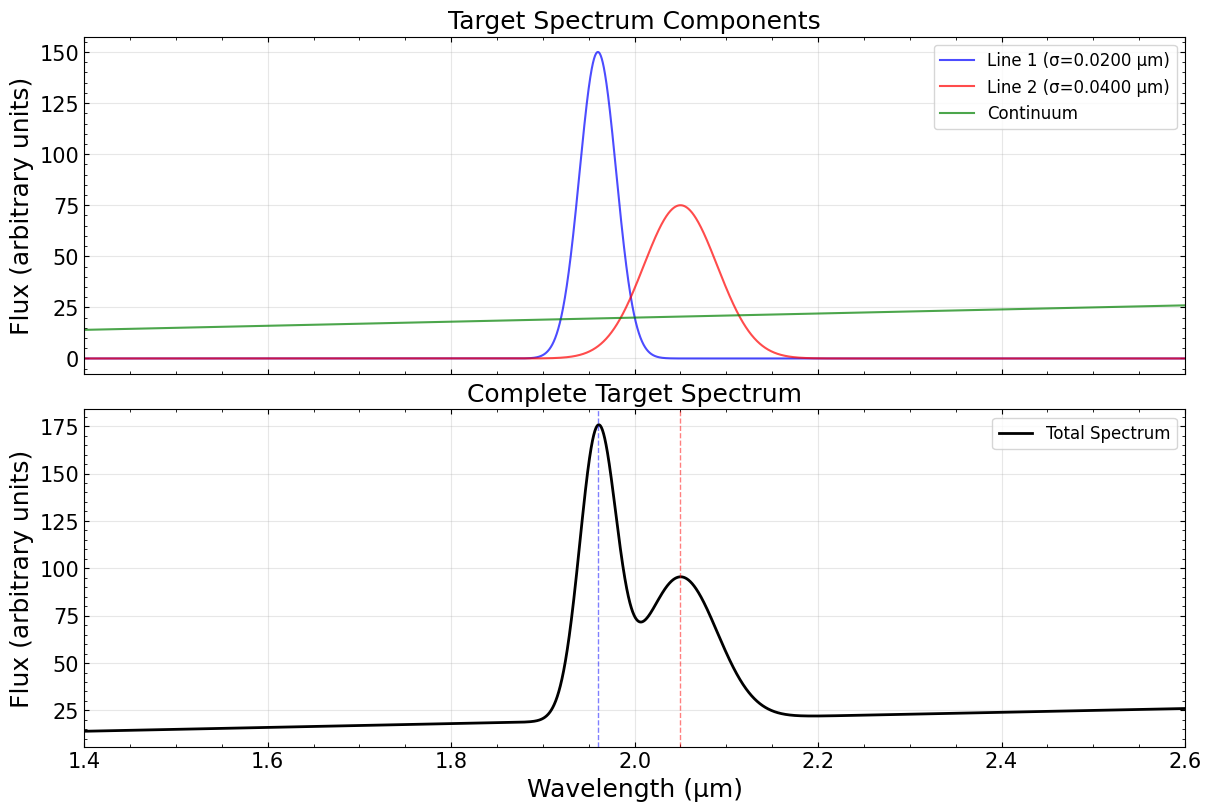


=== Target Spectrum Statistics ===
Total flux range: 14.0 - 175.7
Line 1 peak SNR (relative to continuum): 7.5
Line 2 peak SNR (relative to continuum): 3.8
Line 1 FWHM: 0.0471 μm
Line 2 FWHM: 0.0942 μm


In [3]:
# Generate wavelength grid and target spectrum
wavelength = np.linspace(wavelength_min, wavelength_max, n_pixels)


def gaussian_line(wavelength, center, amplitude, width):
    """Generate Gaussian emission line."""
    return amplitude * np.exp(-0.5 * ((wavelength - center) / width) ** 2)


def linear_continuum(wavelength, reference_amplitude, slope, reference_wavelength):
    """Generate linear continuum."""
    return reference_amplitude + slope * (wavelength - reference_wavelength)


# Build the target spectrum
line1_component = gaussian_line(wavelength, line1_center, line1_amplitude, line1_width)
line2_component = gaussian_line(wavelength, line2_center, line2_amplitude, line2_width)
continuum_component = linear_continuum(wavelength, continuum_amplitude, continuum_slope, continuum_reference)
true_spectrum = line1_component + line2_component + continuum_component

# Visualize the target spectrum
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top plot: Individual components
axes[0].plot(wavelength, line1_component, "b-", alpha=0.7, linewidth=1.5, label=f"Line 1 (σ={line1_width:.4f} μm)")
axes[0].plot(wavelength, line2_component, "r-", alpha=0.7, linewidth=1.5, label=f"Line 2 (σ={line2_width:.4f} μm)")
axes[0].plot(wavelength, continuum_component, "g-", alpha=0.7, linewidth=1.5, label="Continuum")
axes[0].set_ylabel("Flux (arbitrary units)")
axes[0].set_title("Target Spectrum Components")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(wavelength_min, wavelength_max)

# Bottom plot: Complete spectrum
axes[1].plot(wavelength, true_spectrum, "k-", linewidth=2, label="Total Spectrum")
axes[1].axvline(line1_center, color="blue", linestyle="--", alpha=0.5, linewidth=1)
axes[1].axvline(line2_center, color="red", linestyle="--", alpha=0.5, linewidth=1)
axes[1].set_xlabel("Wavelength (μm)")
axes[1].set_ylabel("Flux (arbitrary units)")
axes[1].set_title("Complete Target Spectrum")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(wavelength_min, wavelength_max)

plt.show()

# Print some statistics
print("\n=== Target Spectrum Statistics ===")
print(f"Total flux range: {np.min(true_spectrum):.1f} - {np.max(true_spectrum):.1f}")
print(f"Line 1 peak SNR (relative to continuum): {line1_amplitude / continuum_amplitude:.1f}")
print(f"Line 2 peak SNR (relative to continuum): {line2_amplitude / continuum_amplitude:.1f}")
print(f"Line 1 FWHM: {2.355 * line1_width:.4f} μm")
print(f"Line 2 FWHM: {2.355 * line2_width:.4f} μm")

## 2. Observation Simulation

Simulate realistic SPHEREx narrow-band observations with proper noise modeling.

In [4]:
# === Observation Simulation Parameters ===
# Users can modify these to test different observation scenarios

# Number of observations
n_observations = 800

# Filter bandwidth (microns) - this is the key undersampling parameter
filter_bandwidth = 10 * sigma  # microns

# Detector/instrument parameters
gain = 30.0  # Electrons per ADU (analog-to-digital unit)
read_noise = 70.0  # Read noise (electrons)
sky_background = 300.0  # Sky background flux (arbitrary units)
dark_current = 0.5  # Dark current (electrons/second)
exposure_time = 1.0  # Exposure time (seconds)

# Additional systematic noise (fraction of signal)
systematic_noise_fraction = 0.1  # 10% systematic noise

print("=== Observation Simulation Parameters ===")
print(f"Number of observations: {n_observations}")
print(f"Filter bandwidth: {filter_bandwidth:.3f} μm")

# Calculate undersampling factor
min_line_width = min(line1_width, line2_width)
undersampling_factor = filter_bandwidth / min_line_width
print(f"Undersampling factor: {undersampling_factor:.1f} (bandwidth/line_width)")
print(
    f"coverage factor (N_obs * bandwidth / total_width) = {n_observations * filter_bandwidth / (wavelength_max - wavelength_min):.1f}"
)

print(f"\nInstrument parameters:")
print(f"  Gain: {gain} e-/ADU")
print(f"  Read noise: {read_noise} e-")
print(f"  Sky background: {sky_background} units")
print(f"  Systematic noise: {systematic_noise_fraction * 100:.0f}% of signal")

=== Observation Simulation Parameters ===
Number of observations: 800
Filter bandwidth: 0.200 μm
Undersampling factor: 10.0 (bandwidth/line_width)
coverage factor (N_obs * bandwidth / total_width) = 133.3

Instrument parameters:
  Gain: 30.0 e-/ADU
  Read noise: 70.0 e-
  Sky background: 300.0 units
  Systematic noise: 10% of signal


In [5]:
# Generate observation centers and simulate observations
margin = filter_bandwidth / 2
obs_centers = np.random.uniform(wavelength_min + margin, wavelength_max - margin, n_observations)
obs_centers = np.sort(obs_centers)

# Simulate observations with proper noise model
obs_fluxes = []
obs_uncertainties = []
obs_bandwidths = []

print("Simulating observations...")

for i, center in enumerate(obs_centers):
    band_edges = (center - filter_bandwidth / 2, center + filter_bandwidth / 2)
    mask = (wavelength >= band_edges[0]) & (wavelength <= band_edges[1])

    if np.sum(mask) > 0:
        true_avg_flux = np.mean(true_spectrum[mask])
        total_signal_electrons = (true_avg_flux + sky_background) * gain * exposure_time
        photon_noise = np.sqrt(abs(total_signal_electrons))
        read_noise_electrons = read_noise
        dark_noise_electrons = np.sqrt(dark_current * exposure_time * np.sum(mask))
        total_noise_electrons = np.sqrt(photon_noise**2 + read_noise_electrons**2 + dark_noise_electrons**2)
        total_noise_flux = total_noise_electrons / (gain * exposure_time)
        systematic_noise = systematic_noise_fraction * true_avg_flux
        total_noise_flux = np.sqrt(total_noise_flux**2 + systematic_noise**2)
        observed_flux = true_avg_flux + np.random.normal(0, total_noise_flux)

        obs_fluxes.append(observed_flux)
        obs_uncertainties.append(total_noise_flux)
        obs_bandwidths.append(filter_bandwidth)

obs_fluxes = np.array(obs_fluxes)
obs_uncertainties = np.array(obs_uncertainties)
obs_bandwidths = np.array(obs_bandwidths)

# Calculate and display observation statistics
peak_snr = np.max(obs_fluxes / obs_uncertainties)
median_snr = np.median(obs_fluxes / obs_uncertainties)
min_snr = np.min(obs_fluxes / obs_uncertainties)

print(f"Successfully simulated {len(obs_fluxes)} observations")
print(f"\n=== Observation Statistics ===")
print(f"Flux range: {np.min(obs_fluxes):.1f} - {np.max(obs_fluxes):.1f}")
print(f"Uncertainty range: {np.min(obs_uncertainties):.2f} - {np.max(obs_uncertainties):.2f}")
print(f"Signal-to-Noise Ratio (SNR):")
print(f"  Peak SNR: {peak_snr:.1f}")
print(f"  Median SNR: {median_snr:.1f}")
print(f"  Minimum SNR: {min_snr:.1f}")

Simulating observations...
Successfully simulated 800 observations

=== Observation Statistics ===
Flux range: 3.5 - 114.6
Uncertainty range: 4.37 - 10.30
Signal-to-Noise Ratio (SNR):
  Peak SNR: 11.2
  Median SNR: 5.2
  Minimum SNR: 0.8


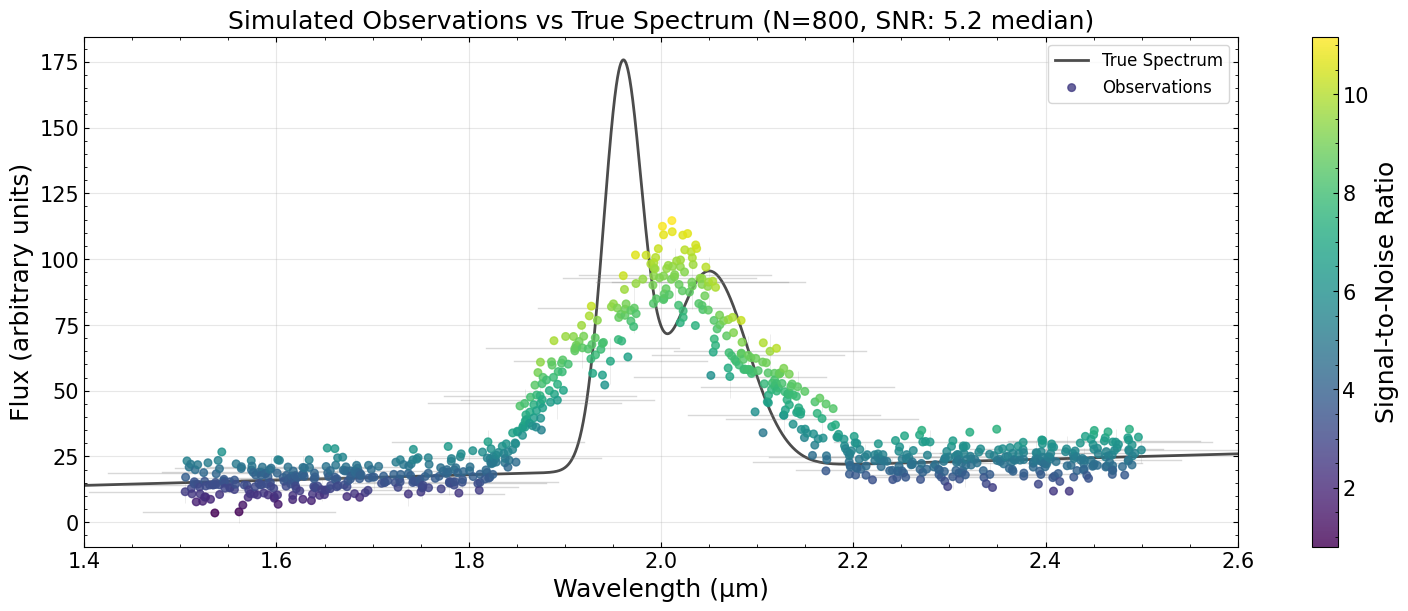


=== Observation Summary ===
Total observations: 800
Median SNR: 5.2
SNR range: 0.8 - 11.2
Error bars show: horizontal = bandwidth (0.200 μm), vertical = flux uncertainty


In [6]:
# Visualize the simulated observations
fig, ax = plt.subplots(figsize=(14, 6))

# Plot true spectrum
ax.plot(wavelength, true_spectrum, "k-", linewidth=2, alpha=0.7, label="True Spectrum")

# Calculate SNR for color coding
snr_values = obs_fluxes / obs_uncertainties

# Scatter plot with SNR color coding
scatter = ax.scatter(
    obs_centers, obs_fluxes, c=snr_values, s=30, cmap="viridis", alpha=0.8, label="Observations", zorder=5
)

# Add error bars for a subset of observations to show bandwidth
n_show = min(50, len(obs_centers))
show_indices = np.linspace(0, len(obs_centers) - 1, n_show, dtype=int)
for idx in show_indices:
    center = obs_centers[idx]
    flux = obs_fluxes[idx]
    bandwidth = obs_bandwidths[idx]
    uncertainty = obs_uncertainties[idx]

    # Horizontal error bar showing bandwidth (thin line)
    ax.plot([center - bandwidth / 2, center + bandwidth / 2], [flux, flux], "gray", alpha=0.3, linewidth=1)
    # Vertical error bar showing flux uncertainty
    ax.errorbar(center, flux, yerr=uncertainty, fmt="none", ecolor="gray", alpha=0.2, linewidth=0.5)

ax.set_xlabel("Wavelength (μm)")
ax.set_ylabel("Flux (arbitrary units)")
ax.set_title(f"Simulated Observations vs True Spectrum (N={n_observations}, SNR: {np.median(snr_values):.1f} median)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(wavelength_min, wavelength_max)

# Add colorbar for SNR
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Signal-to-Noise Ratio")

plt.show()

print(f"\n=== Observation Summary ===")
print(f"Total observations: {len(obs_centers)}")
print(f"Median SNR: {np.median(snr_values):.1f}")
print(f"SNR range: {np.min(snr_values):.1f} - {np.max(snr_values):.1f}")
print(f"Error bars show: horizontal = bandwidth ({filter_bandwidth:.3f} μm), vertical = flux uncertainty")

## 3. Configure Ensemble Reconstruction

Set up the configuration for ensemble reconstruction with multiple members.

In [7]:
# Create ensemble configuration
from sympy import use


ensemble_config = SEDConfig(
    # Wavelength and resolution
    wavelength_range=(wavelength_min, wavelength_max),
    global_resolution=500,  # Resolution for reconstruction
    # Ensemble parameters
    ensemble_size=5,  # Number of ensemble members
    ensemble_random_seed=1027,  # Base seed for reproducible ensembles
    # Reconstruction parameters
    epochs=3000,  # Moderate number of epochs for demo
    learning_rate=1e-3,
    learning_rate_scheduler_type="cosine_warmup",
    learning_rate_warmup_epochs=300,
    learning_rate_min_factor=0.05,
    regularization_weight=1e-2,
    cwt_scales=[1.0, 2.0, 3.0],
    # Settings for EMA smoothing
    use_ema=True,
    ema_decay=0.99,
    ema_start_epoch=2000,
    # DIP architecture
    dip_filters=32,
    dip_depth=3,
    dip_noise_std=0.1,
    dip_noise_jitter_initial_ratio=0.3,
    # Quality filtering
    sigma_threshold=3.0,
    enable_sigma_clip=True,
    # Device configuration
    device=device,
)

print(f"Ensemble Configuration:")
print(f"  Number of ensemble members: {ensemble_config.ensemble_size}")
print(f"  Base random seed: {ensemble_config.ensemble_random_seed}")
print(f"  Device: {ensemble_config.device}")
print(
    f"  Wavelength range: {ensemble_config.wavelength_range[0]:.2f} - {ensemble_config.wavelength_range[1]:.2f} microns"
)
print(f"  Reconstruction resolution: {ensemble_config.global_resolution} points")
print(f"  Epochs per member: {ensemble_config.epochs}")
print(f"  Learning rate: {ensemble_config.learning_rate}")
print(f"  Regularization weight: {ensemble_config.regularization_weight}")

Ensemble Configuration:
  Number of ensemble members: 5
  Base random seed: 1027
  Device: mps
  Wavelength range: 1.40 - 2.60 microns
  Reconstruction resolution: 500 points
  Epochs per member: 3000
  Learning rate: 0.001
  Regularization weight: 0.01


In [8]:
# Create the BandData object
band_data = BandData(
    band="Sim",  # Simulation band name
    flux=obs_fluxes,
    flux_error=obs_uncertainties,
    wavelength_center=obs_centers,
    bandwidth=obs_bandwidths,
)

# Create band data dictionary
band_data_dict = {"Sim": band_data}

print("✓ BandData object created")
print(f"Band: {band_data.band}")
print(f"Number of observations: {len(band_data.flux)}")
print(f"Flux range: {np.min(band_data.flux):.1f} - {np.max(band_data.flux):.1f}")
print(f"Uncertainty range: {np.min(band_data.flux_error):.2f} - {np.max(band_data.flux_error):.2f}")

✓ BandData object created
Band: Sim
Number of observations: 800
Flux range: 3.5 - 114.6
Uncertainty range: 4.37 - 10.30


In [9]:
# Initialize reconstructor with ensemble configuration
reconstructor = SEDReconstructor(ensemble_config)

# Run ensemble reconstruction from BandData objects
print("Starting ensemble reconstruction...")
print(f"Running {ensemble_config.ensemble_size} independent ensemble members")
print(f"Training duration per member: {ensemble_config.epochs / 1000:.1f}-{ensemble_config.epochs / 500:.1f} minutes")

ensemble_result = reconstructor.reconstruct_from_data(
    band_data_dict,
    metadata={
        "method": "ensemble_demo",
        "synthetic_spectrum": True,
        "observation_parameters": {
            "n_observations": n_observations,
            "filter_bandwidth": filter_bandwidth,
            "median_snr": median_snr,
            "line1_center": line1_center,
            "line2_center": line2_center,
        },
        "data_source": "synthetic_simulation_with_realistic_noise",
    },
)

print(f"\nEnsemble reconstruction completed!")
print(f"  Ensemble size: {ensemble_result.ensemble_size}")
print(f"  Wavelength points: {len(ensemble_result.wavelength)}")
print(f"  Wavelength range: {ensemble_result.wavelength[0]:.3f} - {ensemble_result.wavelength[-1]:.3f} μm")
print(
    f"  Mean χ²_ν across members: {np.mean([r.validation_metrics.chi_squared_reduced for r in ensemble_result.member_results]):.3f}"
)
print(f"  Average solver time: {np.mean([r.solver_time for r in ensemble_result.member_results]):.2f}s per member")
print(f"  Total ensemble time: {sum(r.solver_time for r in ensemble_result.member_results):.2f}s")

Starting ensemble reconstruction...
Running 5 independent ensemble members
Training duration per member: 3.0-6.0 minutes


Optimizing Spectrum: 100%|██████████| 3000/3000 [00:24<00:00, 123.75it/s, Loss=3.2252e+01, Data=3.1197e+01, Reg=1.0556e+00, LR=5.32e-05]
  -> Poor fit or underestimated errors (reduced chi-squared >> 1)
Optimizing Spectrum: 100%|██████████| 3000/3000 [00:23<00:00, 128.41it/s, Loss=3.6920e+01, Data=3.5744e+01, Reg=1.1759e+00, LR=5.32e-05]
  -> Poor fit or underestimated errors (reduced chi-squared >> 1)
Optimizing Spectrum: 100%|██████████| 3000/3000 [00:22<00:00, 133.10it/s, Loss=3.2501e+01, Data=3.1072e+01, Reg=1.4281e+00, LR=5.32e-05]
  -> Poor fit or underestimated errors (reduced chi-squared >> 1)
Optimizing Spectrum: 100%|██████████| 3000/3000 [00:22<00:00, 133.71it/s, Loss=3.3275e+01, Data=3.2175e+01, Reg=1.1003e+00, LR=5.32e-05]
  -> Poor fit or underestimated errors (reduced chi-squared >> 1)
Optimizing Spectrum: 100%|██████████| 3000/3000 [00:22<00:00, 134.32it/s, Loss=3.2535e+01, Data=3.1252e+01, Reg=1.2831e+00, LR=5.32e-05]
  -> Poor fit or underestimated errors (reduced chi


Ensemble reconstruction completed!
  Ensemble size: 5
  Wavelength points: 500
  Wavelength range: 1.400 - 2.600 μm
  Mean χ²_ν across members: 2.687
  Average solver time: 22.99s per member
  Total ensemble time: 114.94s


## 6. Compare with Single Reconstruction

Run a single reconstruction for comparison to demonstrate the benefits of ensembling.

In [ ]:
# Create single reconstruction configuration (same parameters, ensemble_size=1)

single_config = ensemble_config.copy_with_overrides(ensemble_size=1)

# Run single reconstruction
print("Running single reconstruction for comparison...")
single_reconstructor = SEDReconstructor(single_config)
single_result = single_reconstructor.reconstruct_from_data(
    band_data_dict,
    metadata={
        "method": "single_comparison",
        "synthetic_spectrum": True,
        "observation_parameters": {
            "n_observations": n_observations,
            "filter_bandwidth": filter_bandwidth,
            "median_snr": median_snr,
        },
    },
)

print(f"\nSingle reconstruction completed!")
print(f"  χ²_ν: {single_result.validation_metrics.chi_squared_reduced:.3f}")
print(f"  Solver time: {single_result.solver_time:.2f}s")
print(f"  Residual std: {single_result.validation_metrics.residual_std:.2e}")
print(f"  Weighted residual std: {single_result.validation_metrics.weighted_residual_std:.3f}")
print(f"  Max residual: {single_result.validation_metrics.max_residual:.2e}")

Running single reconstruction for comparison...


Optimizing Spectrum: 100%|██████████| 3000/3000 [00:24<00:00, 123.91it/s, Loss=3.2252e+01, Data=3.1197e+01, Reg=1.0556e+00, LR=5.32e-05]
  -> Poor fit or underestimated errors (reduced chi-squared >> 1)



Single reconstruction completed!
  χ²_ν: 2.706
  Solver time: 24.22s
  Residual std: 6.03e+00
  Weighted residual std: 1.007
  Max residual: 2.94e+01


In [15]:
# Collect quality metrics
single_chi2 = single_result.validation_metrics.chi_squared_reduced
ensemble_chi2_values = [r.validation_metrics.chi_squared_reduced for r in ensemble_result.member_results]
ensemble_mean_chi2 = np.mean(ensemble_chi2_values)
ensemble_std_chi2 = np.std(ensemble_chi2_values)

print("Quality Assessment Comparison:")
print(f"  Single reconstruction χ²_ν: {single_chi2:.3f}")
print(f"  Ensemble χ²_ν: {ensemble_mean_chi2:.3f} ± {ensemble_std_chi2:.3f}")
print(f"  Individual ensemble members χ²_ν: {[f'{c:.3f}' for c in ensemble_chi2_values]}")

# Additional quality metrics
print("\nAdditional Quality Metrics:")
print(f"  Single reconstruction residual std: {single_result.validation_metrics.residual_std:.2e}")
print(
    f"  Ensemble mean residual std: {np.mean([r.validation_metrics.residual_std for r in ensemble_result.member_results]):.2e}"
)
print(f"  Single weighted residual std: {single_result.validation_metrics.weighted_residual_std:.3f}")
print(
    f"  Ensemble mean weighted residual std: {np.mean([r.validation_metrics.weighted_residual_std for r in ensemble_result.member_results]):.3f}"
)

# Performance comparison
print("\nPerformance Analysis:")
print(f"  Single reconstruction time: {single_result.solver_time:.2f}s")
print(f"  Total ensemble time: {sum(r.solver_time for r in ensemble_result.member_results):.2f}s")
print(f"  Average per member: {np.mean([r.solver_time for r in ensemble_result.member_results]):.2f}s")
print(f"  Time overhead factor: {ensemble_config.ensemble_size:.1f}x")

# Identify best/worst members
best_idx = np.argmin(ensemble_chi2_values)
worst_idx = np.argmax(ensemble_chi2_values)
print(f"\nBest ensemble member: {best_idx + 1} with χ²_ν = {ensemble_chi2_values[best_idx]:.3f}")
print(f"Worst ensemble member: {worst_idx + 1} with χ²_ν = {ensemble_chi2_values[worst_idx]:.3f}")

# Improvement assessment
improvement_factor = single_chi2 / ensemble_mean_chi2
print(f"\nEnsemble vs Single:")
print(f"  χ²_ν improvement: {improvement_factor:.2f}x {'better' if improvement_factor > 1 else 'worse'}")
print(f"  Uncertainty quantification: {'Available' if ensemble_config.ensemble_size > 1 else 'Not available'}")
print(f"  Failure resilience: {'High' if ensemble_config.ensemble_size > 1 else 'Low'}")

# Weighted residual statistics (should be ~1 for good fit)
print(f"\nWeighted Residual Statistics (should be ~1.0 for good fit):")
print(f"  Single reconstruction weighted residual std: {single_result.validation_metrics.weighted_residual_std:.3f}")
print(
    f"  Ensemble mean weighted residual std: {np.mean([r.validation_metrics.weighted_residual_std for r in ensemble_result.member_results]):.3f}"
)

Quality Assessment Comparison:
  Single reconstruction χ²_ν: 2.706
  Ensemble χ²_ν: 2.687 ± 0.050
  Individual ensemble members χ²_ν: ['2.706', '2.682', '2.609', '2.765', '2.674']

Additional Quality Metrics:
  Single reconstruction residual std: 6.03e+00
  Ensemble mean residual std: 5.99e+00
  Single weighted residual std: 1.007
  Ensemble mean weighted residual std: 1.003

Performance Analysis:
  Single reconstruction time: 24.22s
  Total ensemble time: 114.94s
  Average per member: 22.99s
  Time overhead factor: 5.0x

Best ensemble member: 3 with χ²_ν = 2.609
Worst ensemble member: 4 with χ²_ν = 2.765

Ensemble vs Single:
  χ²_ν improvement: 1.01x better
  Uncertainty quantification: Available
  Failure resilience: High

Weighted Residual Statistics (should be ~1.0 for good fit):
  Single reconstruction weighted residual std: 1.007
  Ensemble mean weighted residual std: 1.003


## 7. Quality Assessment Comparison

Compare the quality metrics between single reconstruction and ensemble members.

In [16]:
# Collect quality metrics
single_chi2 = single_result.validation_metrics.chi_squared_reduced
ensemble_chi2_values = [r.validation_metrics.chi_squared_reduced for r in ensemble_result.member_results]
ensemble_mean_chi2 = np.mean(ensemble_chi2_values)
ensemble_std_chi2 = np.std(ensemble_chi2_values)

print("Quality Assessment Comparison:")
print(f"  Single reconstruction χ²_ν: {single_chi2:.3f}")
print(f"  Ensemble χ²_ν: {ensemble_mean_chi2:.3f} ± {ensemble_std_chi2:.3f}")
print(f"  Individual ensemble members χ²_ν: {[f'{c:.3f}' for c in ensemble_chi2_values]}")

# Additional quality metrics
print("\nAdditional Quality Metrics:")
print(f"  Single reconstruction residual RMS: {single_result.validation_metrics.residual_std:.2e}")
print(
    f"  Ensemble mean residual RMS: {np.mean([r.validation_metrics.weighted_residual_std for r in ensemble_result.member_results]):.2e}"
)

# Performance comparison
print("\nPerformance Analysis:")
print(f"  Single reconstruction time: {single_result.solver_time:.2f}s")
print(f"  Total ensemble time: {sum(r.solver_time for r in ensemble_result.member_results):.2f}s")
print(f"  Average per member: {np.mean([r.solver_time for r in ensemble_result.member_results]):.2f}s")
print(f"  Time overhead factor: {ensemble_config.ensemble_size:.1f}x")

# Identify best/worst members
best_idx = np.argmin(ensemble_chi2_values)
worst_idx = np.argmax(ensemble_chi2_values)
print(f"\nBest ensemble member: {best_idx + 1} with χ²_ν = {ensemble_chi2_values[best_idx]:.3f}")
print(f"Worst ensemble member: {worst_idx + 1} with χ²_ν = {ensemble_chi2_values[worst_idx]:.3f}")

# Improvement assessment
improvement_factor = single_chi2 / ensemble_mean_chi2
print(f"\nEnsemble vs Single:")
print(f"  χ²_ν improvement: {improvement_factor:.2f}x {'better' if improvement_factor > 1 else 'worse'}")
print(f"  Uncertainty quantification: {'Available' if ensemble_config.ensemble_size > 1 else 'Not available'}")
print(f"  Failure resilience: {'High' if ensemble_config.ensemble_size > 1 else 'Low'}")

Quality Assessment Comparison:
  Single reconstruction χ²_ν: 2.706
  Ensemble χ²_ν: 2.687 ± 0.050
  Individual ensemble members χ²_ν: ['2.706', '2.682', '2.609', '2.765', '2.674']

Additional Quality Metrics:
  Single reconstruction residual RMS: 6.03e+00
  Ensemble mean residual RMS: 1.00e+00

Performance Analysis:
  Single reconstruction time: 24.22s
  Total ensemble time: 114.94s
  Average per member: 22.99s
  Time overhead factor: 5.0x

Best ensemble member: 3 with χ²_ν = 2.609
Worst ensemble member: 4 with χ²_ν = 2.765

Ensemble vs Single:
  χ²_ν improvement: 1.01x better
  Uncertainty quantification: Available
  Failure resilience: High


## 8. Visualization of Results

Create comprehensive plots showing the ensemble results, uncertainty bands, and comparison with single reconstruction.

/var/folders/z5/qygyj_xj7dq109c9rzqq2wv40000gn/T/ipykernel_25257/3266102232.py:105: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


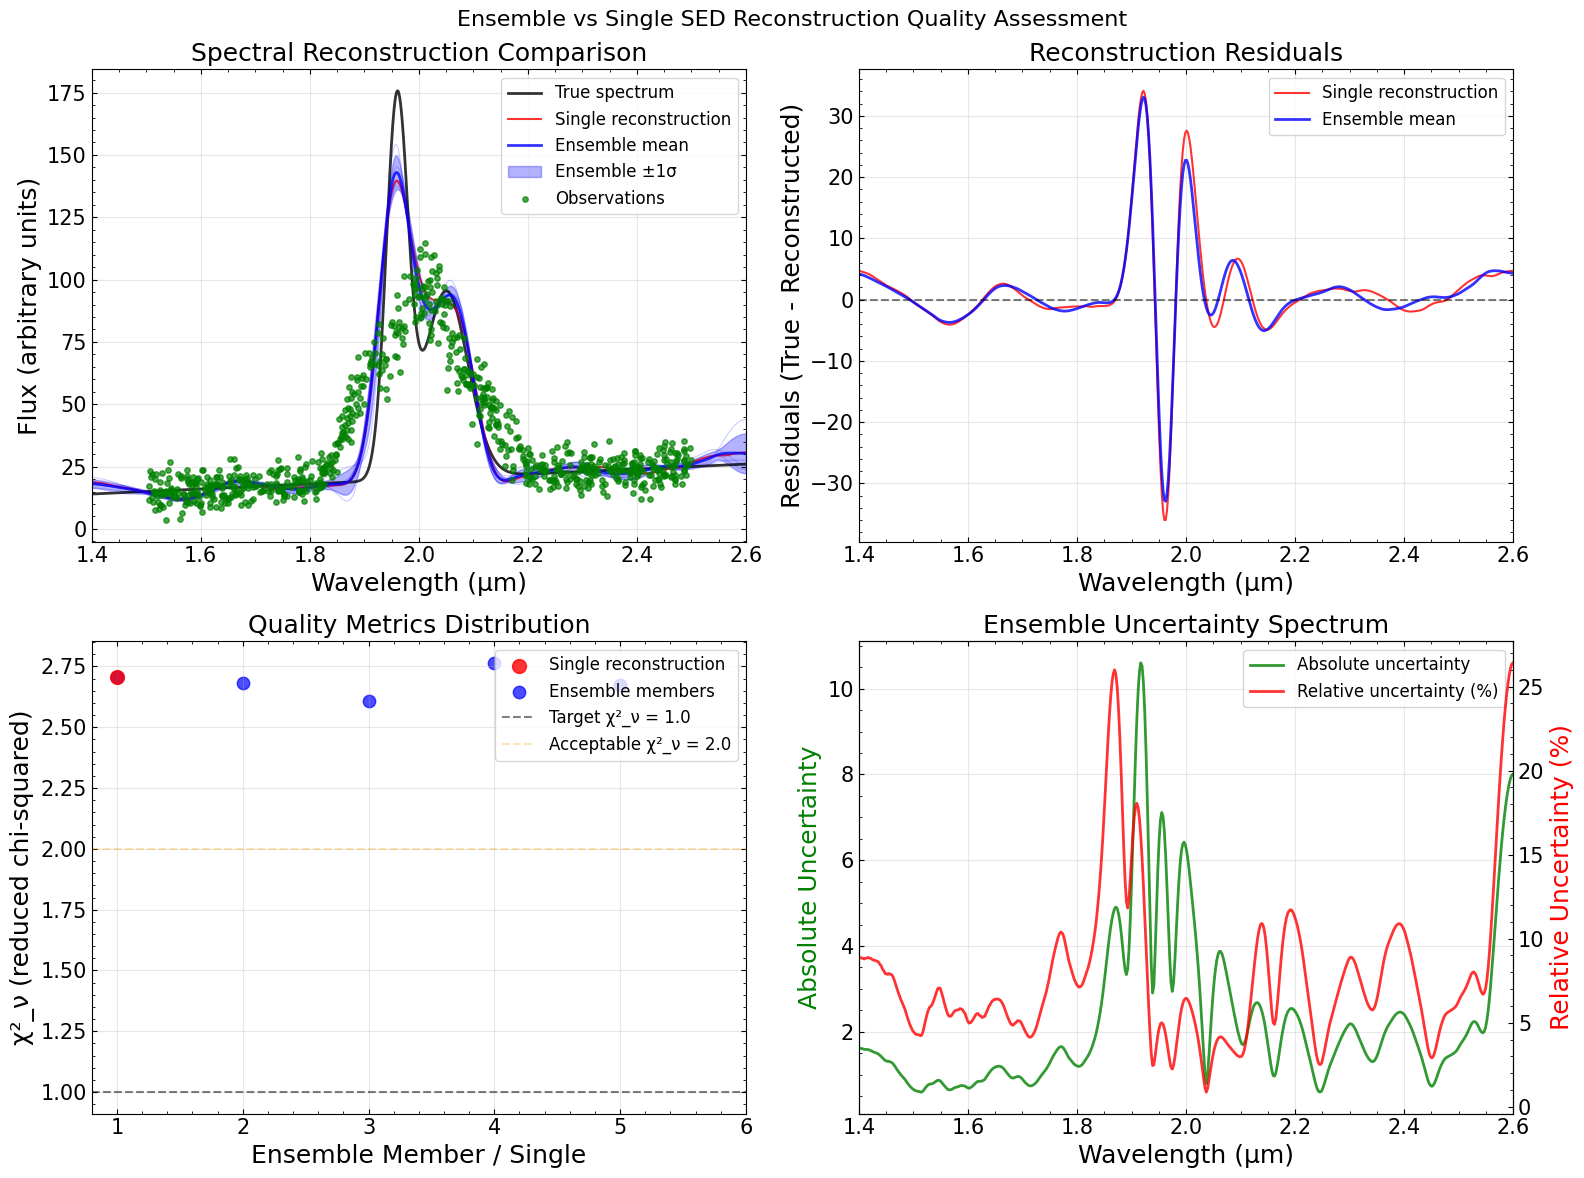


Ensemble Reconstruction Summary:
  Mean absolute uncertainty: 2.27e+00
  Max absolute uncertainty: 1.06e+01
  Min absolute uncertainty: 5.91e-01
  Mean relative uncertainty: 7.78%
  Max relative uncertainty: 26.41%


In [17]:
# Interpolate true spectrum to reconstruction wavelength grid
true_interp_single = np.interp(single_result.wavelength, wavelength, true_spectrum)
true_interp_ensemble = np.interp(ensemble_result.wavelength, wavelength, true_spectrum)

# Create comprehensive quality assessment plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Ensemble vs Single SED Reconstruction Quality Assessment", fontsize=16)

# Plot 1: Spectral reconstruction comparison
ax1 = axes[0, 0]
ax1.plot(wavelength, true_spectrum, "k-", alpha=0.8, linewidth=2, label="True spectrum")
ax1.plot(single_result.wavelength, single_result.flux, "r-", alpha=0.8, linewidth=1.5, label="Single reconstruction")

# Plot ensemble mean with uncertainty band
ax1.plot(ensemble_result.wavelength, ensemble_result.mean_flux, "b-", alpha=0.8, linewidth=2, label="Ensemble mean")
ax1.fill_between(
    ensemble_result.wavelength,
    ensemble_result.mean_flux - ensemble_result.std_flux,
    ensemble_result.mean_flux + ensemble_result.std_flux,
    alpha=0.3,
    color="blue",
    label="Ensemble ±1σ",
)

# Plot individual ensemble members (faint)
for i, member_flux in enumerate(ensemble_result.ensemble_fluxes):
    ax1.plot(ensemble_result.wavelength, member_flux, "b-", alpha=0.2, linewidth=0.8)

# Plot observations
ax1.scatter(obs_centers, obs_fluxes, c="green", s=15, alpha=0.7, label="Observations", zorder=10)

ax1.set_xlabel("Wavelength (μm)")
ax1.set_ylabel("Flux (arbitrary units)")
ax1.set_title("Spectral Reconstruction Comparison")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(wavelength_min, wavelength_max)

# Plot 2: Residuals comparison
ax2 = axes[0, 1]
single_residual = single_result.flux - true_interp_single
ensemble_residual = ensemble_result.mean_flux - true_interp_ensemble

ax2.plot(single_result.wavelength, single_residual, "r-", alpha=0.8, linewidth=1.5, label="Single reconstruction")
ax2.plot(ensemble_result.wavelength, ensemble_residual, "b-", alpha=0.8, linewidth=2, label="Ensemble mean")
ax2.axhline(y=0, color="k", linestyle="--", alpha=0.5)
ax2.set_xlabel("Wavelength (μm)")
ax2.set_ylabel("Residuals (True - Reconstructed)")
ax2.set_title("Reconstruction Residuals")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(wavelength_min, wavelength_max)

# Plot 3: Quality metrics distribution
ax3 = axes[1, 0]
ax3.scatter([1], [single_chi2], color="red", s=100, alpha=0.8, label="Single reconstruction", zorder=5)
ax3.scatter(
    range(1, len(ensemble_chi2_values) + 1),
    ensemble_chi2_values,
    color="blue",
    s=80,
    alpha=0.7,
    label="Ensemble members",
)
ax3.axhline(y=1.0, color="k", linestyle="--", alpha=0.5, label="Target χ²_ν = 1.0")
ax3.axhline(y=2.0, color="orange", linestyle="--", alpha=0.3, label="Acceptable χ²_ν = 2.0")
ax3.set_xlabel("Ensemble Member / Single")
ax3.set_ylabel("χ²_ν (reduced chi-squared)")
ax3.set_title("Quality Metrics Distribution")
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xticks(range(1, len(ensemble_chi2_values) + 2))

# Plot 4: Uncertainty spectrum
ax4 = axes[1, 1]
uncertainty_spectrum = ensemble_result.std_flux
relative_uncertainty = uncertainty_spectrum / ensemble_result.mean_flux

# Plot absolute uncertainty
ax4_twin = ax4.twinx()
line1 = ax4.plot(
    ensemble_result.wavelength, uncertainty_spectrum, "g-", linewidth=2, alpha=0.8, label="Absolute uncertainty"
)
line2 = ax4_twin.plot(
    ensemble_result.wavelength,
    relative_uncertainty * 100,
    "r-",
    linewidth=2,
    alpha=0.8,
    label="Relative uncertainty (%)",
)

ax4.set_xlabel("Wavelength (μm)")
ax4.set_ylabel("Absolute Uncertainty", color="g")
ax4_twin.set_ylabel("Relative Uncertainty (%)", color="r")
ax4.set_title("Ensemble Uncertainty Spectrum")
ax4.grid(True, alpha=0.3)
ax4.set_xlim(wavelength_min, wavelength_max)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax4.legend(lines, labels, loc="upper right")

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nEnsemble Reconstruction Summary:")
print(f"  Mean absolute uncertainty: {np.mean(uncertainty_spectrum):.2e}")
print(f"  Max absolute uncertainty: {np.max(uncertainty_spectrum):.2e}")
print(f"  Min absolute uncertainty: {np.min(uncertainty_spectrum):.2e}")
print(f"  Mean relative uncertainty: {np.mean(relative_uncertainty) * 100:.2f}%")
print(f"  Max relative uncertainty: {np.max(relative_uncertainty) * 100:.2f}%")

## 9. Individual Ensemble Member Analysis

Examine the variation among individual ensemble members.

In [ ]:
# Also save the comparison results
comparison_df = pd.DataFrame(
    {
        "method": ["single", "ensemble_mean", "ensemble_median"],
        "chi2_reduced": [single_chi2, ensemble_mean_chi2, np.median(chi2_values)],
        "residual_std": [
            single_result.validation_metrics.residual_std,
            np.mean([r.validation_metrics.residual_std for r in ensemble_result.member_results]),
            np.mean([r.validation_metrics.residual_std for r in ensemble_result.member_results]),
        ],
        "weighted_residual_std": [
            single_result.validation_metrics.weighted_residual_std,
            np.mean([r.validation_metrics.weighted_residual_std for r in ensemble_result.member_results]),
            np.mean([r.validation_metrics.weighted_residual_std for r in ensemble_result.member_results]),
        ],
        "solver_time_s": [
            single_result.solver_time,
            np.mean([r.solver_time for r in ensemble_result.member_results]),
            np.mean([r.solver_time for r in ensemble_result.member_results]),
        ],
    }
)

NameError: name 'chi2_values' is not defined

## 10. Statistical Analysis of Ensemble Results

Detailed statistical analysis of the ensemble performance.

In [ ]:
# Statistical analysis of ensemble results
print("Statistical Analysis of Ensemble Results:")
print("=" * 50)

# Chi-squared statistics
print(f"\nχ²_ν Statistics:")
print(f"  Mean: {np.mean(chi2_values):.4f}")
print(f"  Median: {np.median(chi2_values):.4f}")
print(f"  Standard deviation: {np.std(chi2_values):.4f}")
print(f"  Min: {np.min(chi2_values):.4f}")
print(f"  Max: {np.max(chi2_values):.4f}")
print(f"  Range: {np.max(chi2_values) - np.min(chi2_values):.4f}")

# Ensemble consistency
print(f"\nEnsemble Consistency:")
flux_ensemble_std = np.std(ensemble_result.ensemble_fluxes, axis=0)
flux_ensemble_mean = ensemble_result.mean_flux
relative_uncertainty = flux_ensemble_std / flux_ensemble_mean

print(f"  Mean relative uncertainty: {np.mean(relative_uncertainty) * 100:.2f}%")
print(f"  Median relative uncertainty: {np.median(relative_uncertainty) * 100:.2f}%")
print(f"  Max relative uncertainty: {np.max(relative_uncertainty) * 100:.2f}%")
print(f"  Min relative uncertainty: {np.min(relative_uncertainty) * 100:.2f}%")

# Quality assessment
good_members = np.sum(np.array(chi2_values) < 2.0)  # χ²_ν < 2 is considered good
excellent_members = np.sum(np.array(chi2_values) < 1.5)  # χ²_ν < 1.5 is excellent

print(f"\nQuality Assessment:")
print(
    f"  Members with χ²_ν < 1.5 (excellent): {excellent_members}/{len(chi2_values)} ({excellent_members / len(chi2_values) * 100:.1f}%)"
)
print(
    f"  Members with χ²_ν < 2.0 (good): {good_members}/{len(chi2_values)} ({good_members / len(chi2_values) * 100:.1f}%)"
)
print(f"  Single reconstruction χ²_ν < 2.0: {'Yes' if single_chi2 < 2.0 else 'No'}")
print(f"  Ensemble mean better than single: {'Yes' if ensemble_mean_chi2 < single_chi2 else 'No'}")

# Robustness metrics
print(f"\nRobustness Metrics:")
ensemble_robustness = 1.0 / (1.0 + np.std(chi2_values))  # Higher is more robust
print(f"  Ensemble robustness score: {ensemble_robustness:.3f}")
print(f"  Consistency across wavelength: {1.0 - np.std(relative_uncertainty):.3f}")

# Comparison with single reconstruction
print(f"\nSingle vs Ensemble Comparison:")
improvement_factor = single_chi2 / ensemble_mean_chi2
print(f"  χ²_ν improvement factor: {improvement_factor:.2f}x")
print(f"  Time overhead: {ensemble_config.ensemble_size}x (by design)")
print(f"  Uncertainty quantification: {'Yes' if ensemble_config.ensemble_size > 1 else 'No'}")
print(f"  Failure resilience: {'High' if ensemble_config.ensemble_size > 1 else 'Low'}")

# Peak recovery analysis
print(f"\nPeak Recovery Analysis:")
line1_true_peak = line1_amplitude
line2_true_peak = line2_amplitude

# Find peaks in ensemble mean
from scipy.signal import find_peaks

ensemble_peaks, _ = find_peaks(ensemble_result.mean_flux, height=np.max(ensemble_result.mean_flux) * 0.3)
single_peaks, _ = find_peaks(single_result.flux, height=np.max(single_result.flux) * 0.3)

print(f"  True spectrum peaks: 2 (at {line1_center:.3f} and {line2_center:.3f} μm)")
print(f"  Single reconstruction peaks: {len(single_peaks)}")
print(f"  Ensemble mean peaks: {len(ensemble_peaks)}")
print(f"  Peak detection consistency: {'Good' if len(ensemble_peaks) >= 2 else 'Needs improvement'}")

## 11. Save Ensemble Results

Save the ensemble reconstruction results for later analysis.

In [ ]:
# Create output directory
output_dir = Path("ensemble_results")
print(f"Saving ensemble results to {output_dir}")

# Save all ensemble results
ensemble_result.save_all(output_dir)

print("\nSaved files:")
print(f"  - {output_dir}/ensemble_mean_spectrum.csv (mean spectrum with uncertainties)")
print(f"  - {output_dir}/ensemble_metadata.json (ensemble metadata and statistics)")
print(f"  - {output_dir}/member_XX_spectrum.csv (individual member spectra)")

# Also save the comparison results
comparison_df = pd.DataFrame(
    {
        "method": ["single", "ensemble_mean", "ensemble_median"],
        "chi2_reduced": [single_chi2, ensemble_mean_chi2, np.median(chi2_values)],
        "residual_rms": [
            single_result.validation_metrics.residual_rms,
            np.mean([r.validation_metrics.residual_rms for r in ensemble_result.member_results]),
            np.mean([r.validation_metrics.residual_rms for r in ensemble_result.member_results]),
        ],
        "solver_time_s": [
            single_result.solver_time,
            np.mean([r.solver_time for r in ensemble_result.member_results]),
            np.mean([r.solver_time for r in ensemble_result.member_results]),
        ],
    }
)

comparison_path = output_dir / "quality_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"  - {comparison_path} (quality metrics comparison)")

# Save the synthetic data and configuration
synthetic_data = {
    "wavelength": wavelength.tolist(),
    "true_spectrum": true_spectrum.tolist(),
    "observations": {
        "flux": obs_fluxes.tolist(),
        "flux_error": obs_uncertainties.tolist(),
        "wavelength_center": obs_centers.tolist(),
        "bandwidth": obs_bandwidths.tolist(),
        "n_observations": len(obs_fluxes),
        "median_snr": float(median_snr),
    },
    "target_parameters": {
        "line1_center": line1_center,
        "line1_amplitude": line1_amplitude,
        "line1_width": line1_width,
        "line2_center": line2_center,
        "line2_amplitude": line2_amplitude,
        "line2_width": line2_width,
        "continuum_amplitude": continuum_amplitude,
        "continuum_slope": continuum_slope,
        "continuum_reference": continuum_reference,
    },
    "observation_parameters": {
        "filter_bandwidth": filter_bandwidth,
        "gain": gain,
        "read_noise": read_noise,
        "sky_background": sky_background,
        "systematic_noise_fraction": systematic_noise_fraction,
        "random_seed": 42,
    },
}

synthetic_path = output_dir / "synthetic_data.json"
with open(synthetic_path, "w") as f:
    json.dump(synthetic_data, f, indent=2)
print(f"  - {synthetic_path} (synthetic data and metadata)")

# Save ensemble configuration
config_dict = ensemble_config.to_dict()
config_path = output_dir / "ensemble_config.json"
with open(config_path, "w") as f:
    json.dump(config_dict, f, indent=2)
print(f"  - {config_path} (ensemble configuration)")

print(f"\nEnsemble demonstration completed successfully!")
print(f"Results saved to: {output_dir.absolute()}")

# Final summary
print(f"\n=== FINAL ENSEMBLE SUMMARY ===")
print(f"Reconstruction Quality:")
print(f"  Single χ²_ν: {single_chi2:.3f}")
print(f"  Ensemble χ²_ν: {ensemble_mean_chi2:.3f} ± {ensemble_std_chi2:.3f}")
print(f"  Best ensemble member χ²_ν: {np.min(chi2_values):.3f}")
print(f"\nEnsemble Benefits:")
print(f"  Uncertainty quantification: Available ({np.mean(relative_uncertainty) * 100:.1f}% mean relative uncertainty)")
print(f"  Robustness: {ensemble_robustness:.3f} (higher is better)")
print(f"  Quality consistency: {good_members}/{len(chi2_values)} members with χ²_ν < 2.0")
print(f"  Failure resilience: High (multiple independent runs)")
print(f"\nPerformance:")
print(f"  Total computation time: {sum(r.solver_time for r in ensemble_result.member_results):.1f}s")
print(
    f"  Time vs single: {sum(r.solver_time for r in ensemble_result.member_results) / single_result.solver_time:.1f}x"
)
print(f"  Parallelization potential: {ensemble_config.ensemble_size}x (members can run in parallel)")